<a href="https://colab.research.google.com/github/AjeySrini/AI_Projects/blob/main/EDA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Ajey Srinivasu

Assignment: EDA Analysis

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()


(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


In [2]:
# Shape of DataFrame
print("Shape of DataFrame:", df.shape)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values count
missing_counts = df.isnull().sum()
print("\nMissing Values Count:\n", missing_counts)

# Missing percentage
missing_percent = (missing_counts / len(df)) * 100
print("\nMissing Percentage:\n", missing_percent.round(2))

Shape of DataFrame: (200, 6)

Data Types:
 order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object

Missing Values Count:
 order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64

Missing Percentage:
 order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


In [15]:
df['order_value'] = df['order_value'].fillna(df['order_value'].median())
df['delivery_days'] = df['delivery_days'].fillna(df['delivery_days'].median())

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

print("Median order_value:", df['order_value'].median())
print("Median delivery_days:", df['delivery_days'].median())
print("Mode rating:", df['rating'].mode()[0])

Median order_value: 2934.0
Median delivery_days: 8.0
Mode rating: 5


In [4]:
summary = df.describe()
print(summary)

          order_id   order_value  delivery_days      rating
count   200.000000    200.000000     200.000000  200.000000
mean   1100.500000   3653.015000       7.820000    3.295000
std      57.879185   8909.737238       3.971962    1.536156
min    1001.000000    204.000000       1.000000    1.000000
25%    1050.750000   1663.750000       4.000000    2.000000
50%    1100.500000   2934.000000       8.000000    3.000000
75%    1150.250000   3938.500000      12.000000    5.000000
max    1200.000000  95000.000000      14.000000    5.000000


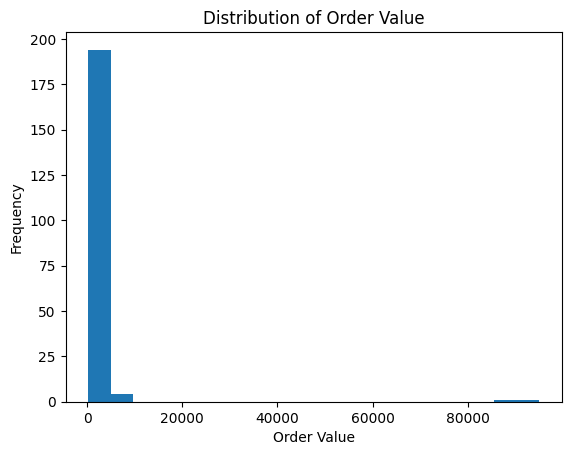

In [5]:
import matplotlib.pyplot as plt

plt.hist(df['order_value'], bins=20)
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

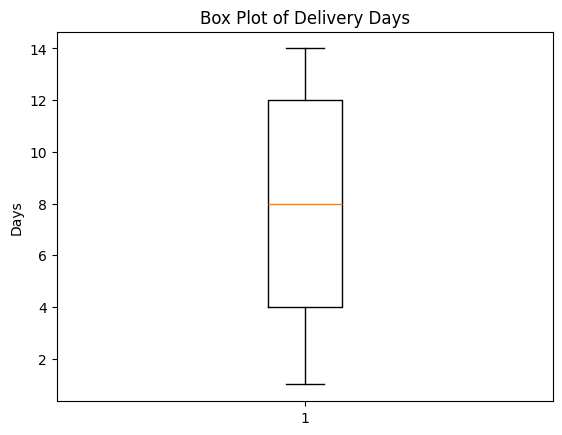

In [6]:
plt.boxplot(df['delivery_days'])
plt.title("Box Plot of Delivery Days")
plt.ylabel("Days")
plt.show()

In [7]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

               order_id  order_value  delivery_days    rating
order_id       1.000000    -0.091937       0.005661  0.043039
order_value   -0.091937     1.000000       0.137433  0.025935
delivery_days  0.005661     0.137433       1.000000 -0.124674
rating         0.043039     0.025935      -0.124674  1.000000


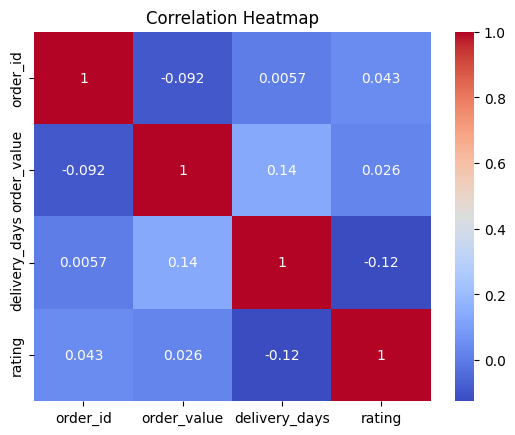

In [8]:
import seaborn as sns

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()